In [1]:
from enum import IntFlag, auto

class Args(IntFlag):
    X = auto()
    A = auto()
    D = auto()
    E = auto()

    @classmethod
    def from_code(cls, code: int):
        match code:
            case 0:
                return cls.A
            case 1:
                return cls.D | cls.A
            case 2:
                return cls.E | cls.A
            case 3:
                return cls.E | cls.D | cls.A
            case 4:
                return cls.E | cls.D
            case _:
                raise ValueError

    @property
    def valency_code(self):
        for code in range(5):
            if Args.from_code(code) == self:
                return code
        return None

In [2]:
from attrs import frozen, field
from functools import reduce

@frozen
class Clause:
    valency: Args = field()
    @valency.validator
    def _check_valency(self, attr, val):
        if val.valency_code is None:
            raise ValueError("verb has invalid valency")

    args: Args = field()
    @args.validator
    def _check_args(self, attr, val):
        if (val & ~Args.X) not in self.valency:
            raise ValueError("arguments do not match verb valency")
    
    topic: Args = field()
    @topic.validator
    def _check_topic(self, attr, val):
        if len(list(val)) > 1:
            raise ValueError("cannot have multiple topics")
        elif val not in self.args:
            raise ValueError("topic must be in arguments")

    @classmethod
    def from_valency_args(cls, valency: int, args: list[Args]):
        return cls(Args.from_code(valency), reduce(Args.__or__, args), args[0])

    @classmethod
    def from_args(cls, args: list[Args]):
        valency = reduce(Args.__or__, args)
        return cls(valency, valency, args[0])

    @property
    def tokens(self):
        return (self.topic, self.valency) + tuple(self.args & ~self.topic)[::-1]

    def __repr__(self):
        return '(' + ', '.join([self.topic._name_, str(self.valency.valency_code), *(arg._name_ for arg in self.tokens[2:])]) + ')'

    @property
    def full_valency(self):
        return self.valency == self.args

    @property
    def normal_order(self):
        return self.topic == list(self.args)[-1]

In [3]:
from more_itertools import circular_shifts, powerset

def valency_powerset(valency: Args):
    return [subset for subset in (reduce(Args.__or__, args) for args in powerset(valency) if len(args) > 0) if (Args.A in subset) or (Args.E in subset)]
all_valencies = [subset for subset in (reduce(Args.__or__, args) for args in powerset((Args.E, Args.D, Args.A)) if len(args) > 0) if subset.valency_code is not None]
all_clauses = sorted(
    (Clause.from_valency_args(valency.valency_code, order) for valency in all_valencies for args in valency_powerset(valency) for order in circular_shifts(args)),
    key = lambda c: (c.valency, c.args, -c.topic)
)

unpreferred_clauses = {
    Clause.from_valency_args(2, [Args.E]),
    Clause.from_valency_args(3, [Args.E]),
}

print(f'{'clause':20s}{'full':10s}{'normal':10s}{'unpreferred':10s}')
for clause in all_clauses:
    print(f'{str(clause):20s}{'*' if clause.full_valency else '':10s}{'*' if clause.normal_order else '':10s}{'*' if clause in unpreferred_clauses else ''}')

clause              full      normal    unpreferred
(A, 0)              *         *         
(A, 1)                        *         
(D, 1, A)           *         *         
(A, 1, D)           *                   
(A, 2)                        *         
(E, 2)                        *         *
(E, 2, A)           *         *         
(A, 2, E)           *                   
(E, 4)                        *         
(E, 4, D)           *         *         
(D, 4, E)           *                   
(A, 3)                        *         
(D, 3, A)                     *         
(A, 3, D)                               
(E, 3)                        *         *
(E, 3, A)                     *         
(A, 3, E)                               
(E, 3, D)                     *         
(D, 3, E)                               
(E, 3, D, A)        *         *         
(D, 3, E, A)        *                   
(A, 3, E, D)        *                   


In [4]:
@frozen
class ComplexSentence:
    main: Clause
    rel: Clause
    rel_head: Args = field()
    @rel_head.validator
    def _check_rel_head(self, attr, val):
        if len(list(val)) > 1:
            raise ValueError("rel clause can only modify one argument")
        if val not in self.main.args:
            raise ValueError("rel_head must be an argument in main clause")

    def __repr__(self):
        tokens = []
        for i, token in enumerate(self.main.tokens):
            if i == 1:
                tokens.append(str(token.valency_code))
            elif token == self.rel_head:
                tokens.append(self.rel_head._name_ + ':r' + str(self.rel))
            else:
                tokens.append(token._name_)
        return '(' + ', '.join(tokens) + ')'

    @property
    def reduced(self) -> tuple[Args]:
        idx = self.main.tokens.index(self.rel_head)
        return self.main.tokens[:idx+1] + self.rel.tokens[1:] + self.main.tokens[idx+1:]
        
    @property
    def reduced_repr(self) -> str:
        tokens = [str(token.valency_code) if i == 1 else token._name_ for i, token in enumerate(self.main.tokens)]
        idx = self.main.tokens.index(self.rel_head)
        tokens = tokens[:idx+1] + [str(token.valency_code) if i == 0 else token._name_ for i, token in enumerate(self.rel.tokens[1:])] + tokens[idx+1:]
        return '(' + ', '.join(tokens) + ')'

    @property
    def garden_path(self):
        if self.rel_head not in self.rel.args or self.rel_head == self.rel.topic:
            return False
        elif self.rel_head == self.main.topic or self.rel_head != self.main.tokens[-1] or not self.main.full_valency:
            return True
        else:
            return False

In [5]:
from itertools import product

all_complex_sentences = {ComplexSentence(mc, rc, rel_head) for mc, rc in product(all_clauses, repeat=2) for rel_head in mc.args}
garden_path_sentences = {sentence for sentence in all_complex_sentences if sentence.garden_path}

def complexity(s: ComplexSentence):
    return s.main.valency, s.rel.valency, s.main.args, s.rel.args

for sentence in sorted(garden_path_sentences, key=complexity):
    print(f'{str(sentence):30s}{sentence.reduced_repr:30s}')

(A:r(D, 1, A), 0)             (A, 1, A, 0)                  
(A:r(E, 2, A), 0)             (A, 2, A, 0)                  
(A:r(D, 3, A), 0)             (A, 3, A, 0)                  
(A:r(E, 3, A), 0)             (A, 3, A, 0)                  
(A:r(D, 3, E, A), 0)          (A, 3, E, A, 0)               
(A:r(E, 3, D, A), 0)          (A, 3, D, A, 0)               
(A:r(D, 1, A), 1)             (A, 1, A, 1)                  
(A:r(D, 1, A), 1, D)          (A, 1, A, 1, D)               
(D:r(A, 1, D), 1, A)          (D, 1, D, 1, A)               
(A:r(E, 2, A), 1)             (A, 2, A, 1)                  
(A:r(E, 2, A), 1, D)          (A, 2, A, 1, D)               
(D:r(E, 4, D), 1, A)          (D, 4, D, 1, A)               
(A:r(D, 3, A), 1)             (A, 3, A, 1)                  
(A:r(E, 3, A), 1)             (A, 3, A, 1)                  
(A:r(E, 3, D, A), 1)          (A, 3, D, A, 1)               
(A:r(D, 3, E, A), 1)          (A, 3, E, A, 1)               
(D:r(A, 3, D), 1, A)    

In [172]:
from itertools import chain
from operator import attrgetter
from more_itertools import map_reduce, partition

full_valency_mc_sentences = {sentence for sentence in all_complex_sentences if sentence.main.full_valency}
full_valency_sentences = {sentence for sentence in full_valency_mc_sentences if sentence.rel.full_valency}
unpreferred_rc_sentences = {sentence for sentence in all_complex_sentences if sentence.rel in unpreferred_clauses}
non_pathological_sentences = full_valency_mc_sentences - unpreferred_rc_sentences

reduced_rcs = map_reduce(all_complex_sentences, keyfunc=attrgetter('reduced_repr'))
reduced_rcs_without_pathological_sentences = map_reduce(non_pathological_sentences, keyfunc=attrgetter('reduced_repr'))
properly_ambiguous_sentences, properly_unambiguous_sentences = map(set, map(chain.from_iterable, partition(lambda v: len(v) == 1, reduced_rcs.values())))
ambiguous_sentences, unambiguous_sentences = map(set, map(chain.from_iterable, partition(lambda v: len(v) == 1, reduced_rcs_without_pathological_sentences.values())))

In [173]:
unambiguous_sentences <= properly_unambiguous_sentences

False

In [174]:
ambiguous_sentences <= properly_ambiguous_sentences

True

In [175]:
print(f'{len(properly_unambiguous_sentences)} out of all {len(all_complex_sentences)} complex sentence types are unambiguous')
print(f'{len(unambiguous_sentences)} out of {len(full_valency_mc_sentences)} complex sentences w/ full-valency MCs are unambiguous')

345 out of all 880 complex sentence types are unambiguous
245 out of 484 complex sentences w/ full-valency MCs are unambiguous


In [176]:
def predict_ambiguous(sentence: ComplexSentence):
    # perfectly predicts ambiguity if both MC and RC have all possible core arguments
    # has perfect specificity if either MC or RC is missing core arguments
    if sentence.main.topic != sentence.rel.topic:
        return False
    if sentence.rel_head == sentence.main.topic and len(sentence.rel.args) == 1:
        return False
    
    args = sentence.main.tokens[:1] + sentence.main.tokens[2:]
    if sentence.rel_head != args[0] and sentence.rel_head != args[-1]:
        return False

    return True

sentences_of_interest = sorted(unambiguous_sentences, key=complexity) + sorted(ambiguous_sentences, key=complexity)

for reduced_rc, sentences in ((sentence.reduced_repr, reduced_rcs[sentence.reduced_repr]) for sentence in sentences_of_interest):
    print(reduced_rc)
    for sentence in sentences:
        print(f'\t{str(sentence):30s}{'!!' if predict_ambiguous(sentence) else '.':8s}{'U' if sentence in unambiguous_sentences else '.':8s}{'garden-path' if sentence.garden_path else '':8s}')
    print('')

(A, 0, 0)
	(A:r(A, 0), 0)                .       U               

(A, 1, 0)
	(A:r(A, 1), 0)                .       U               

(A, 1, A, 0)
	(A:r(D, 1, A), 0)             .       U       garden-path

(A, 2, 0)
	(A:r(A, 2), 0)                .       U               
	(A:r(E, 2), 0)                .       .               

(A, 2, A, 0)
	(A:r(E, 2, A), 0)             .       U       garden-path

(A, 4, 0)
	(A:r(E, 4), 0)                .       U               

(A, 4, D, 0)
	(A:r(E, 4, D), 0)             .       U               

(A, 4, E, 0)
	(A:r(D, 4, E), 0)             .       U               

(A, 3, 0)
	(A:r(E, 3), 0)                .       .               
	(A:r(A, 3), 0)                .       U               

(A, 3, E, A, 0)
	(A:r(D, 3, E, A), 0)          .       U       garden-path

(A, 3, D, A, 0)
	(A:r(E, 3, D, A), 0)          .       U       garden-path

(A, 0, 1, D)
	(A:r(A, 0), 1, D)             .       U               

(D, 1, A, 0)
	(D, 1, A:r(A, 0))             .

In [192]:
import pandas as pd

rc_types = pd.DataFrame.from_records(
    data = [
        {
            'main': str(sentence.main),
            'main_val': sentence.main.valency.valency_code,
            'main_topic': sentence.main.topic._name_,
            'rel': str(sentence.rel),
            'rel_val': sentence.rel.valency.valency_code,
            'rel_topic': sentence.rel.topic._name_,
            'rel_head': sentence.rel_head._name_,
            'rel_head_pos': (sentence.main.tokens[:1] + sentence.main.tokens[2:]).index(sentence.rel_head),
            'properly_unambiguous': sentence in properly_unambiguous_sentences,
            'unambiguous': sentence in unambiguous_sentences,
            'garden_path': sentence.garden_path,
        }
        for sentence in full_valency_mc_sentences
    ]
).sort_values(['main_val', 'rel_val'])
rc_types['reducibility'] = [('garden_path' if garden else 'properly_reducible' if prop_unambig else 'reducible' if unambig else 'non_reducible') for (prop_unambig, unambig, garden) in rc_types[['properly_unambiguous', 'unambiguous', 'garden_path']].itertuples(index=False)]
display(rc_types)

,main,main_val,main_topic,rel,rel_val,rel_topic,rel_head,rel_head_pos,properly_unambiguous,unambiguous,garden_path,reducibility
441,"(A, 0)",0,A,"(A, 0)",0,A,A,0,True,True,False,properly_reducible
307,"(A, 0)",0,A,"(D, 1, A)",1,D,A,0,True,True,True,garden_path
361,"(A, 0)",0,A,"(A, 1)",1,A,A,0,True,True,False,properly_reducible
481,"(A, 0)",0,A,"(A, 1, D)",1,A,A,0,False,False,False,non_reducible
229,"(A, 0)",0,A,"(A, 2)",2,A,A,0,False,True,False,reducible
...,...,...,...,...,...,...,...,...,...,...,...,...
308,"(E, 4, D)",4,E,"(D, 4, E)",4,D,E,0,True,True,True,garden_path
353,"(D, 4, E)",4,D,"(E, 4)",4,E,D,0,True,True,False,properly_reducible
370,"(D, 4, E)",4,D,"(E, 4)",4,E,E,1,True,True,False,properly_reducible
377,"(D, 4, E)",4,D,"(D, 4, E)",4,D,E,1,False,False,False,non_reducible


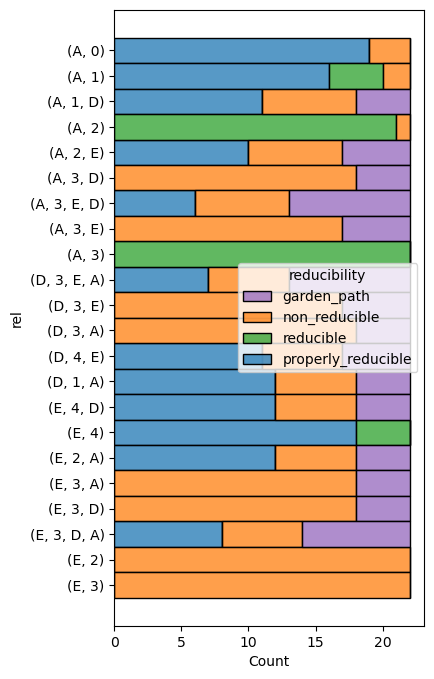

In [204]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.histplot(
    rc_types.sort_values('rel_topic'),
    y = 'rel',
    hue = 'reducibility',
    palette = {
        'properly_reducible': 'tab:blue',
        'reducible': 'tab:green',
        'non_reducible': 'tab:orange',
        'garden_path': 'tab:purple',
    },
    hue_order = ('garden_path', 'non_reducible', 'reducible', 'properly_reducible'),
    discrete = True,
    multiple = 'stack',
)
ax.get_legend().set_loc('right')
ax.figure.set_size_inches(4, 8)

rel_topic,A,D,E
rel_val,,,
0,22,0,0
1,44,22,0
2,44,0,44
3,88,66,88
4,0,22,44


<Axes: xlabel='rel_topic', ylabel='rel_val'>

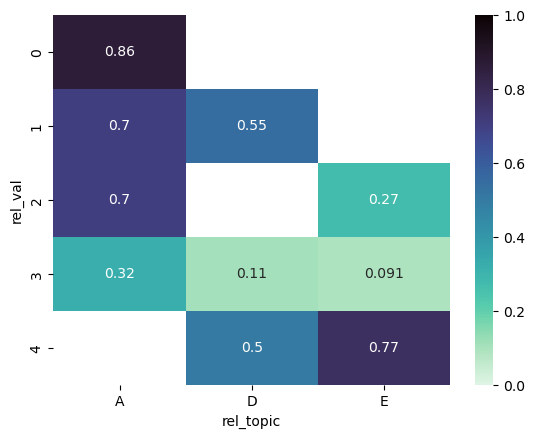

In [212]:
display(pd.crosstab(rc_types['rel_val'], rc_types['rel_topic']))

sns.heatmap(
    pd.crosstab(rc_types['rel_val'], rc_types['rel_topic'], rc_types['reducibility'].isin({'reducible', 'properly_reducible'}), aggfunc='mean'),
    vmin = 0., vmax = 1.,
    cmap = 'mako_r',
    annot = True,
)

rel_topic,A,D,E
rel_head,,,
A,72,40,64
D,63,35,56
E,63,35,56


<Axes: xlabel='rel_topic', ylabel='rel_head'>

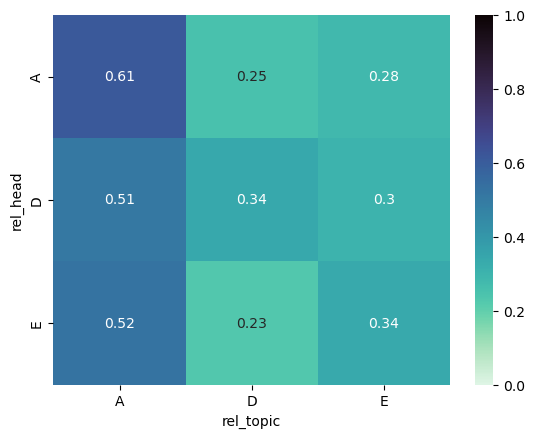

In [214]:
display(pd.crosstab(rc_types['rel_head'], rc_types['rel_topic']))

sns.heatmap(
    pd.crosstab(rc_types['rel_head'], rc_types['rel_topic'], rc_types['reducibility'].isin({'reducible', 'properly_reducible'}), aggfunc='mean'),
    vmin = 0., vmax = 1.,
    cmap = 'mako_r',
    annot = True,
)

rel_topic,A,D,E
main_topic,,,
A,72,40,64
D,63,35,56
E,63,35,56


<Axes: xlabel='rel_topic', ylabel='main_topic'>

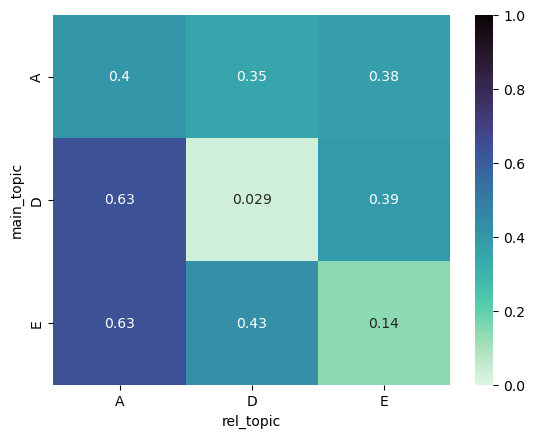

In [213]:
display(pd.crosstab(rc_types['main_topic'], rc_types['rel_topic']))

sns.heatmap(
    pd.crosstab(rc_types['main_topic'], rc_types['rel_topic'], rc_types['reducibility'].isin({'reducible', 'properly_reducible'}), aggfunc='mean'),
    vmin = 0., vmax = 1.,
    cmap = 'mako_r',
    annot = True,
)